# Homework IV - Programing

Grupo 55  
109247 - Ema Ferrão  
109989 - Pedro Aldeia

## Part A - Clustering

Consider the diabetes.csv dataset (available on the course website), which aims to predict
whether a patient has diabetes based on various health-related attributes. Normalize data using
MinMaxScaler. Always use random_state = 42.

### Setup and Data Loading

In [598]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [599]:
# Load data
df = pd.read_csv('diabetes.csv')

In [600]:
# Check the dataset
print("First 5 rows:")
df.head()

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [601]:
# Display basic information
print("\n" + "=" * 150)
print("Dataset Overview:")
print("=" * 150)

print(f"Dataset shape: {df.shape}")

feature_names = df.columns[:-1].tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

target_name = "Outcome"

print(f"\nTarget variable: {target_name} -> {sorted(df[target_name].unique().tolist())}")
print(f"{target_name} distribution:")
print(df[target_name].value_counts())
print(f"{target_name} balance:")
print(df[target_name].value_counts(normalize=True).round(3))

print("\n" + "=" * 150)


Dataset Overview:
Dataset shape: (768, 9)
Features (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target variable: Outcome -> [0, 1]
Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome balance:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64



In [602]:
# Check for missing values
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print("Null Values Summary:")
    print(missing_summary)
else:
    print("No null values detected in the dataset.")

# Columns that can’t realistically be zero
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Count how many zeros in each column
print("\nNumber of points with 0 in columns where 0 is invalid:")
(df[cols_with_invalid_zeros] == 0).sum()

No null values detected in the dataset.

Number of points with 0 in columns where 0 is invalid:


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Since there are too many invalid entries, simply removing them would result in a significant loss of data. Therefore, we replaced zeros with the median value of the corresponding column.

In [603]:
# Replacing missing values with column median

for col in cols_with_invalid_zeros:
    median = df[df[col] != 0][col].median()
    df[col] = np.where(df[col] == 0, median, df[col])

In [604]:
# Prepare data for modeling

mms = MinMaxScaler()
mms.fit(df.drop(columns=[target_name]))
X = mms.transform(df.drop(columns=[target_name]))
y = df[target_name]
np.random.seed(42)

### 1.​ 
Using sklearn, apply K-Means clustering on the normalized data with k = {2, 3, 4, 5, 6, 7, 8,
9, 10, 11}, max_iter = 500. Plot the SSE (sum of squared errors) values for each number of
clusters.

In [605]:
# Calculating SSE for different k values

k = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
results = []

for i in k:
    k_means = KMeans(n_clusters=i, max_iter=500, random_state=42)
    k_means.fit(X)
    results.append(k_means.inertia_)

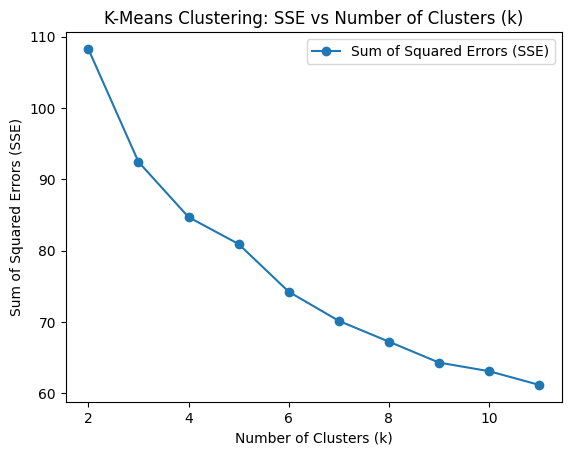

In [606]:
# Plot SSE vs k

plt.plot(k, results, marker='o', label="Sum of Squared Errors (SSE)")
plt.title('K-Means Clustering: SSE vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.legend()
plt.show()

### 2.​
Using k=6, assign each observation to a cluster and classify them based on the majority
class of the cluster they belong to (Example: If cluster A has 100 observations of class 0
and 99 observations of class 1, classify all 199 observations as the majority class: 0 ).
Compute the confusion matrix, accuracy, precision, recall, and F1-score for this
classification model. Is this a good classification model? Justify your answer based on
your experience with classification models, and discuss the limitations of using clustering
for classification tasks.

In [607]:
# Compute confusion matrix and classification metrics for k=6

k_means = KMeans(n_clusters=6, max_iter=500, random_state=42)
k_means.fit(X)

clusters = k_means.labels_
df["Cluster"] = clusters

df["Predicted"] = df.groupby("Cluster")[target_name].transform(lambda x: x.mode()[0])

confusion_matrix = confusion_matrix(df[target_name], df["Predicted"])

accuracy = accuracy_score(df[target_name], df["Predicted"])
precision = precision_score(df[target_name], df["Predicted"])
recall = recall_score(df[target_name], df["Predicted"])
f1_score = f1_score(df[target_name], df["Predicted"])


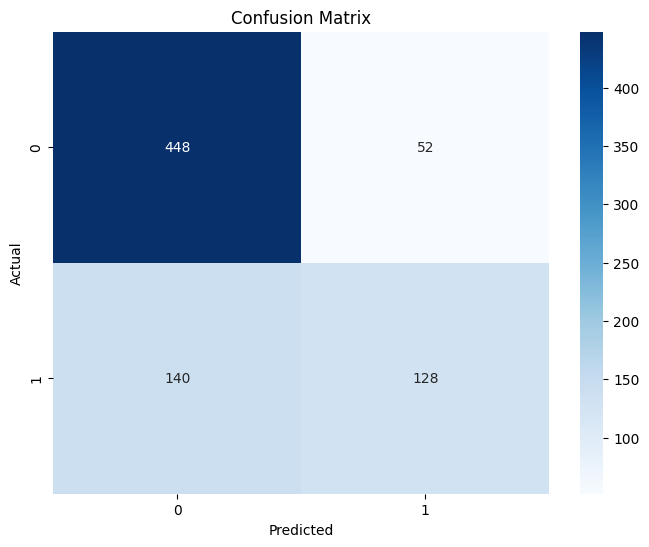

In [608]:
# Plot Confusion Matrix

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

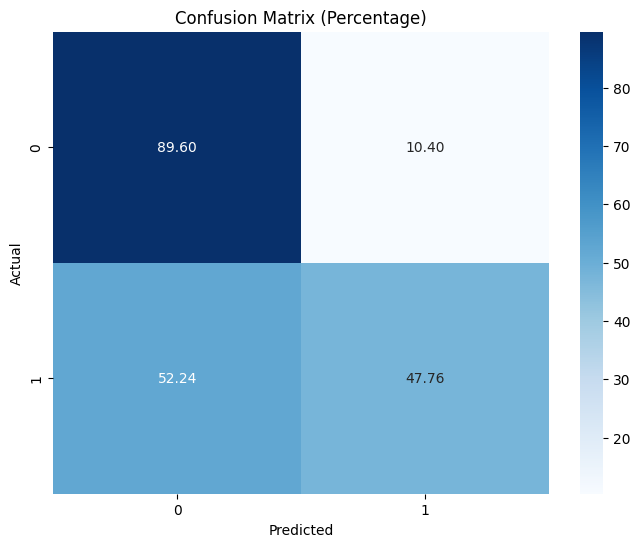

In [609]:
# Plot Confusion Matrix with percentages

plt.figure(figsize=(8, 6))
confusion_matrix_percent = confusion_matrix.astype('float') * 100 / confusion_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(confusion_matrix_percent, annot=True, fmt='.2f', cmap='Blues')
plt.title('Confusion Matrix (Percentage)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [610]:
# Display metrics

print("=" * 20 + "\n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")  
print(f"F1 Score: {f1_score:.4f}")
print("\n" + "=" * 20)


Accuracy: 0.7500
Precision: 0.7111
Recall: 0.4776
F1 Score: 0.5714



K-Means did not perform well for this dataset. Although the accuracy of around 75% may seem acceptable, it is not a reliable indicator of performance in a medical diagnosis context. The recall of 48% is close to random performance, and the F1-score of 0.57 reinforces this weakness. A good diagnostic model should prioritise high recall and F1-score, since the main objective is to correctly identify ill patients. With this model, approximately 52% of diabetic patients would go undetected which is an unacceptable risk in a healthcare setting.

Using clustering for classification tasks comes with significant limitations. Clustering is an unsupervised approach: it groups observations based solely on feature similarity, ignoring class labels entirely. As such, it is highly sensitive to irrelevant or noisy features and offers no control over precision–recall trade-offs, which are critical for diagnostic purposes. Moreover, the quality of the output depends heavily on input choices, such as the number of clusters (k) and the shape of the data distribution. K-Means, in particular, assumes spherical clusters and requires prior knowledge of k, which may not reflect the true structure of the data. Finally, there is no guarantee that the resulting clusters align with the actual disease classes, especially near cluster boundaries.

### 3.​ 
Print the class distribution and the cluster centers for this model. Choose the 3 most
discriminative clusters and interpret the results. What can you conclude about the patients
in those clusters?

In [611]:
# Analyze cluster distribution

print("=" * 30 + "\n")
print("\nCluster distribution:")
print(df["Cluster"].value_counts().sort_index())
print("\n" + "=" * 30)



Cluster distribution:
Cluster
0     90
1    222
2     90
3    122
4     66
5    178
Name: count, dtype: int64



In [612]:
# Analyze distribution per cluster

print("=" * 30 + "\n")
print("Class distribution per cluster:")
class_dist = df.groupby("Cluster")["Outcome"].value_counts().unstack(fill_value=0)
print(class_dist)

print("\nClass distribution per cluster (as percentages):")
class_dist_percent = class_dist.div(class_dist.sum(axis=1), axis=0) * 100
print(class_dist_percent.round(2))
print("\n" + "=" * 30)


Class distribution per cluster:
Outcome    0   1
Cluster         
0         31  59
1        213   9
2         21  69
3         75  47
4         43  23
5        117  61

Class distribution per cluster (as percentages):
Outcome      0      1
Cluster              
0        34.44  65.56
1        95.95   4.05
2        23.33  76.67
3        61.48  38.52
4        65.15  34.85
5        65.73  34.27



In [613]:
# Compute cluster centers

cluster_centers = k_means.cluster_centers_
df_centers_orig = pd.DataFrame(mms.inverse_transform(cluster_centers), columns=feature_names)
df_centers_orig.index.name = "Cluster"
df_centers_orig = df_centers_orig.round(2)

print("=" * 110 + "\n")
print("Cluster Centers (original scale):\n")
print(df_centers_orig.to_string())
print("\n" + "=" * 110)


Cluster Centers (original scale):

         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  DiabetesPedigreeFunction    Age
Cluster                                                                                                     
0               2.24   167.42          73.02          31.81   238.77  36.22                      0.62  30.57
1               1.98   101.12          64.91          22.47   107.63  27.00                      0.41  24.76
2               8.58   159.81          80.41          32.06   165.61  35.30                      0.52  45.60
3               7.77   104.60          74.28          30.37   123.69  32.14                      0.44  37.80
4               4.67   125.61          77.83          28.45   140.94  29.49                      0.42  56.82
5               1.59   115.06          74.02          33.91   131.22  37.22                      0.49  27.06



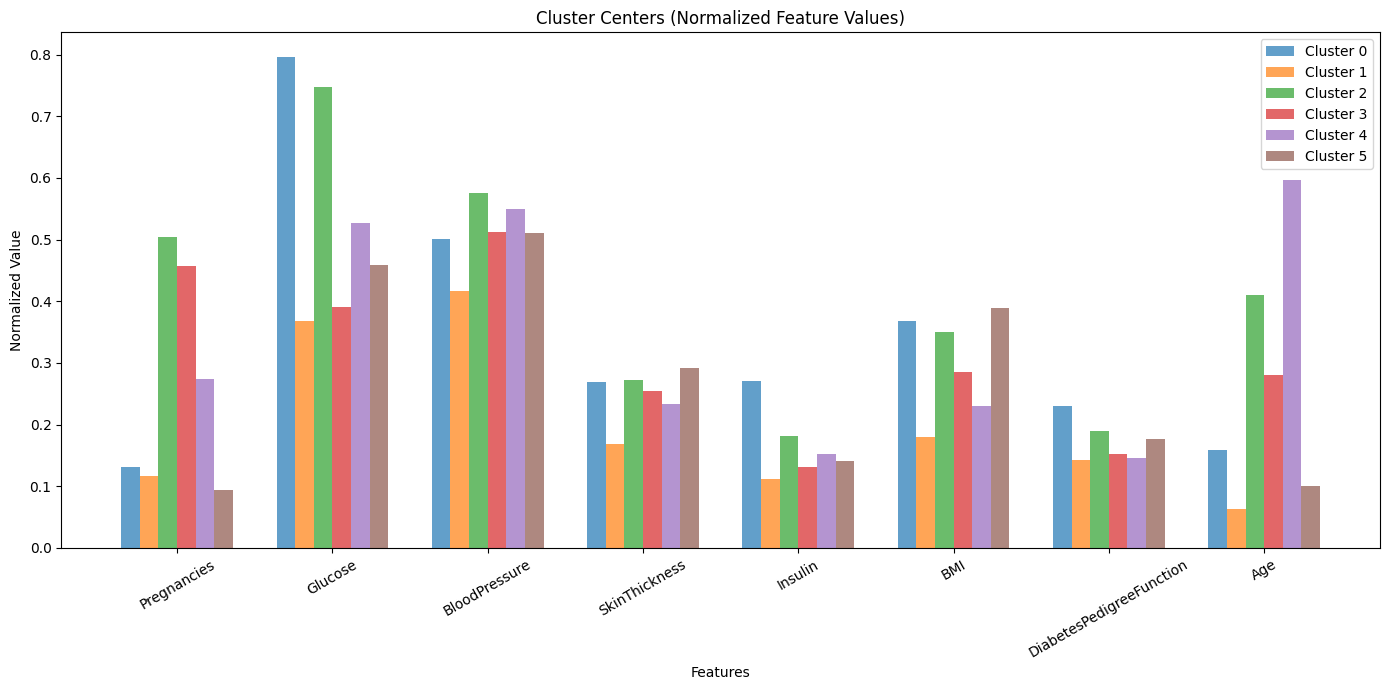

In [614]:
# Plot features for each cluster for better understanding

plt.figure(figsize=(14, 7))
n_clusters = cluster_centers.shape[0]
n_features = cluster_centers.shape[1]
bar_width = 0.12
x = np.arange(n_features)

for idx in range(n_clusters):
    plt.bar(x + idx * bar_width, cluster_centers[idx], width=bar_width, alpha=0.7, label=f'Cluster {idx}')

plt.xticks(x + bar_width * (n_clusters-1)/2, feature_names, rotation=30)
plt.title("Cluster Centers (Normalized Feature Values)")
plt.xlabel("Features")
plt.ylabel("Normalized Value")
plt.legend()
plt.tight_layout()
plt.show()

It is evident that the most discriminative Cluster is cluster 1, where 96% of the cases correspond to outcome 0 (not diabetic). It is followed by Cluster 2 with 77% diabetic and Cluster 5, which has 66% non-diabetic patients. Diagnosis for patients within these last two clusters requires greater caution, since they are less discriminant.

Based on these results, we can identify two main subgroups of non-diabetic patients and one diabetic group:
- Cluster 1 (non-diabetic) - which features a young, metabolically healthy profile: low glucose (~101), low insulin (~107), low BMI (~27) and younger (~25)

- Cluster 5 (non-diabetic) - which features young but heavier individuals with: glucose slightly above normal (~115), moderately high insulin (~131), higher BMI (~37) despite fewer pregnancies (~1.6) and young-adult age (~27)

- Cluster 2 (diabetic) - characterised by older patients (~46) with high glucose (~160), high insulin (~166), and above-average BMI (~35).

## Part B - PCA

Using the same dataset with the same normalization.

### 1.​ 
Apply Principal Component Analysis (PCA) and plot the cumulative explained variance by
the PCA components. How many principal components should be retained to explain at
least 80% of the total variance?

In [615]:
# Creating PCA instance and fitting the data

pca = PCA(random_state=42)
pca.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [616]:
# Fetching explained variance ratio

print("=" * 50 + "\n")
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio by Principal Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")
print("\n" + "=" * 50)


Explained Variance Ratio by Principal Component:
PC1: 0.3567
PC2: 0.2113
PC3: 0.1154
PC4: 0.0986
PC5: 0.0910
PC6: 0.0576
PC7: 0.0418
PC8: 0.0275



In [617]:
# Get total number of components to explain at least 80% variance

cumulative_variance = np.cumsum(explained_variance)

print("=" * 60 + "\n")
print("Cumulative Explained Variance: ")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f}")
print("\n" + "=" * 60)


Cumulative Explained Variance: 
PC1 to PC1: 0.3567
PC1 to PC2: 0.5681
PC1 to PC3: 0.6835
PC1 to PC4: 0.7821
PC1 to PC5: 0.8731
PC1 to PC6: 0.9306
PC1 to PC7: 0.9725
PC1 to PC8: 1.0000



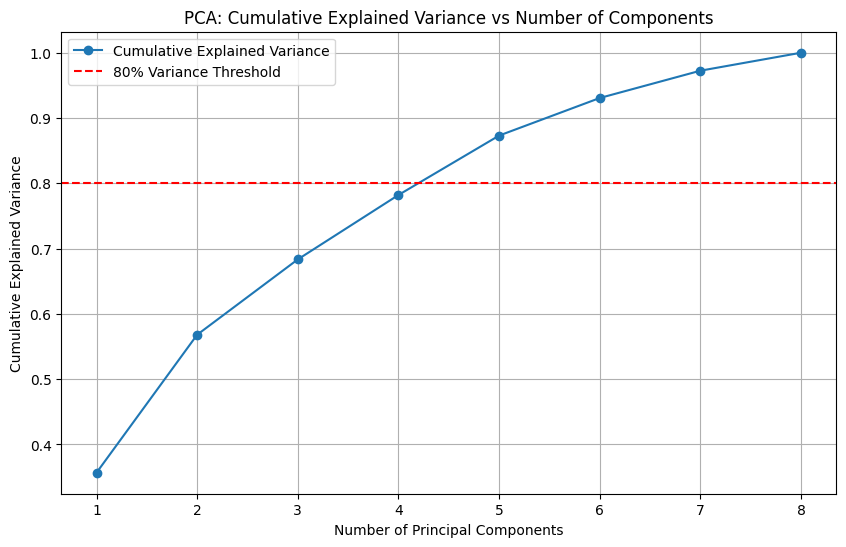

In [618]:
# Plot cumulative explained variance

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance
, marker='o', label='Cumulative Explained Variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Variance Threshold')
plt.title('PCA: Cumulative Explained Variance vs Number of Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid()
plt.show()

Number of components to explain at least 80% variance:  5

### 2.​ 
Plot the class distribution along the first principal component and comment.

In [619]:
# Transform data using PCA

X_pca = pca.transform(X)

pc1_df = pd.DataFrame({
    'PC1': X_pca[:, 0],   # First principal component
    'target': y
})

# Analyse feature contributions to PC1
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)
pc1_loadings = loadings["PC1"].sort_values(ascending=False)
print("=" * 60)
print("\nFeature contributions to PC1:")
print(pc1_loadings)
print("\n" + "=" * 60)



Feature contributions to PC1:
Age                         0.633492
Pregnancies                 0.581428
Glucose                     0.426863
BloodPressure               0.208579
BMI                         0.116267
Insulin                     0.102096
SkinThickness               0.092849
DiabetesPedigreeFunction    0.048470
Name: PC1, dtype: float64



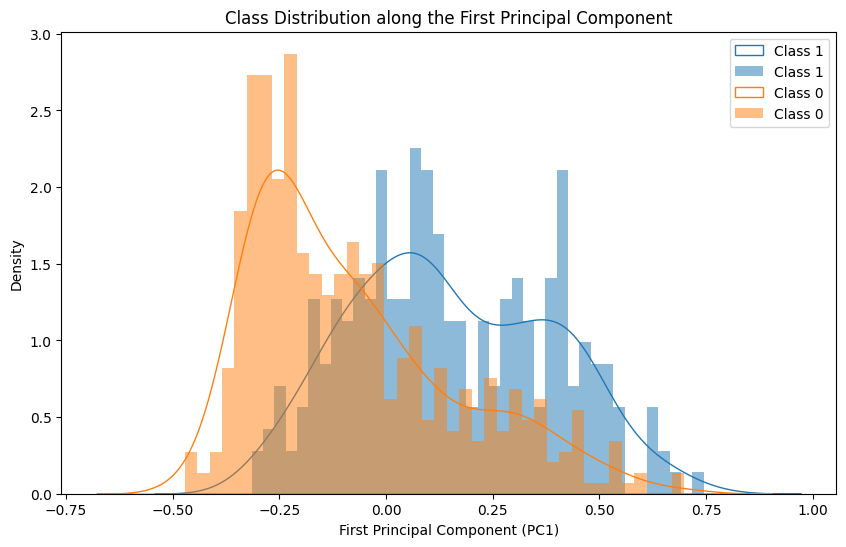

In [620]:
# Plot the class distribution along the first principal component

plt.figure(figsize=(10, 6))
for target_value in pc1_df['target'].unique():
    subset = pc1_df[pc1_df['target'] == target_value]
    sns.kdeplot(subset['PC1'], fill=True, alpha=0, label=f'Class {target_value}')
    plt.hist(subset['PC1'], bins=40, density=True, alpha=0.5, label=f'Class {target_value}') 
plt.title('Class Distribution along the First Principal Component')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Density')
plt.legend()
plt.show()

It becomes clear with the previous plot that, for this dataset, the PC1 manages to partially explain the outcome. For PC1 < -0.2, the class distribution is greatly uneven: class 0 (diabetic) is more prevalent that class 1 (not diabetic).
Then, for PC1 > -0.1, class 1 is predominant to its counterpart, but not as much as the previously mentioned case.

 In this histogram, we observe a great amount of overlap between both classes observations. This shows that PC1 was incapable of distinguishing the two classes properly.

This indicates that the first principal component, which captures the direction of maximum variance in the data, does not correspond to the direction that best separates the two outcome classes.
Therefore, PCA alone provides limited discriminative power for this classification task. 

### 3.​ 
Apply Linear Discriminant Analysis (LDA) and plot the class distribution along the LDA
component. Comment on the results.

In [621]:
# Create LDA instance and fit the data

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

lda_df = pd.DataFrame({
    'LDA1': X_lda[:, 0],   # First LDA component
    'target': y
})

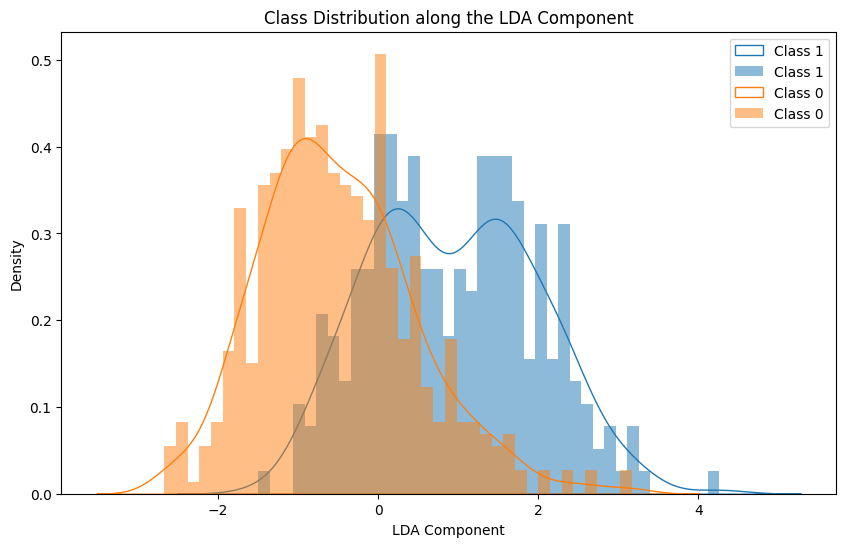

In [622]:
# Plot the class distribution along the LDA component

plt.figure(figsize=(10, 6))
for target_value in lda_df['target'].unique():
    subset = lda_df[lda_df['target'] == target_value]
    sns.kdeplot(subset['LDA1'], fill=True, alpha=0, label=f'Class {target_value}')
    plt.hist(subset['LDA1'], bins=40, density=True, alpha=0.5, label=f'Class {target_value}') 
plt.title('Class Distribution along the LDA Component')
plt.xlabel('LDA Component')
plt.ylabel('Density')
plt.legend()
plt.show()

LDA makes a good job at separating class distributions accordingly to its component. This is because LDA is a supervised method that explicitly seeks a projection that maximises the separation between class means while minimising the variance within each class. 

We can clearly distinguish different distributions for each class across the LDA component, becoming evident that class 0 (not diabetic) is predominant for LDA < 0 and that class 1 (diabetic) is predominant for LDA > 1.
However, there is a great amount of overlap between both classes distributions in range [-1;1]. This leads to the following conclusions:
 - LDA<-1: Patient probably not diabetic;
 - LDA in range [-1;1]: Safer not to conclude anything;
 - LDA>1: Patient probably diabetic.

### 4.​ 
Which of the two methods (PCA or LDA) would be more appropriate for building a
discriminant rule? Justify your answer based on the results obtained and explain why that
method is more suitable.

Between PCA and LDA, LDA is clearly the more appropriate method for building a discriminant rule.
PCA is an unsupervised technique that focuses on capturing the directions of greatest overall variance in the data, regardless of class labels. As seen in the PCA plot, the first component fails to produce a clear separation between diabetic and non-diabetic patients, since the largest sources of variance are not necessarily those that distinguish the classes.

In contrast, LDA is a supervised method that explicitly maximises the ratio of between-class variance to within-class variance. This allows it to find the projection that best separates the two groups, which is clearly visible in the LDA plot where the overlap between classes is much smaller.

Therefore, for tasks involving classification or discrimination between known categories, LDA is more suitable than PCA, as it produces components that directly reflect differences between classes rather than overall data variability.